### Формирование модели машинного обучения

Текущий ноутбук рассматривает анализ датасета [Auto MPG](https://archive.ics.uci.edu/ml/datasets/Auto+MPG).

В работе рассматривается:
1. обучение регрессионной модели для определения потребления автомобилями топлива в городском цикле в галлонах на милю по представленным данным;
2. сохранение обученной модели в виде **конвейера обработки данных** для последующего использования.

In [1]:
import numpy as np
import pandas as pd
from seaborn import pairplot
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from pickle import dump
from pathlib import Path

In [3]:
col_names = ("mpg", "cylinders", "displacement", "horsepower", "weight", 
             "acceleration", "model_year", "origin", "car name")
df = pd.read_csv("C:/ovs/CloudCS-Lab1/data/auto-mpg-data.tsv", 
                 sep='\s+',
                 names=col_names,
                 header=None)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Windows\Temp\ipykernel_2504\540178553.py:4: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


Столбец "`horsepower`" содержит что-то, кроме чисел. Выясним, что.

In [6]:
df["horsepower_floats"] = pd.to_numeric(df["horsepower"], errors='coerce')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mpg                398 non-null    float64
 1   cylinders          398 non-null    int64  
 2   displacement       398 non-null    float64
 3   horsepower         398 non-null    str    
 4   weight             398 non-null    float64
 5   acceleration       398 non-null    float64
 6   model_year         398 non-null    int64  
 7   origin             398 non-null    int64  
 8   car name           398 non-null    str    
 9   horsepower_floats  392 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 31.2 KB


In [8]:
df[df["horsepower_floats"].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car name,horsepower_floats
32,25.0,4,98.0,?,2046.0,19.0,71,1,ford pinto,NaN
126,21.0,6,200.0,?,2875.0,17.0,74,1,ford maverick,NaN
330,40.9,4,85.0,?,1835.0,17.3,80,2,renault lecar deluxe,NaN
336,23.6,4,140.0,?,2905.0,14.3,80,1,ford mustang cobra,NaN
354,34.5,4,100.0,?,2320.0,15.8,81,2,renault 18i,NaN
374,23.0,4,151.0,?,3035.0,20.5,82,1,amc concord dl,NaN


Итак, столбец "`horsepower`" содержит пропуски, обозначенные знаком вопроса. Заменим их на пустые значения, удалим вспомогательный столбец и колонку "`car name`", которая не используется для анализа.

In [9]:
df["horsepower"] = df["horsepower_floats"]
df = df.drop("horsepower_floats", axis=1)
df = df.drop("car name", axis=1)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [11]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


Посмотрим на распределение данных. Какие выводы по ним можно сделать?

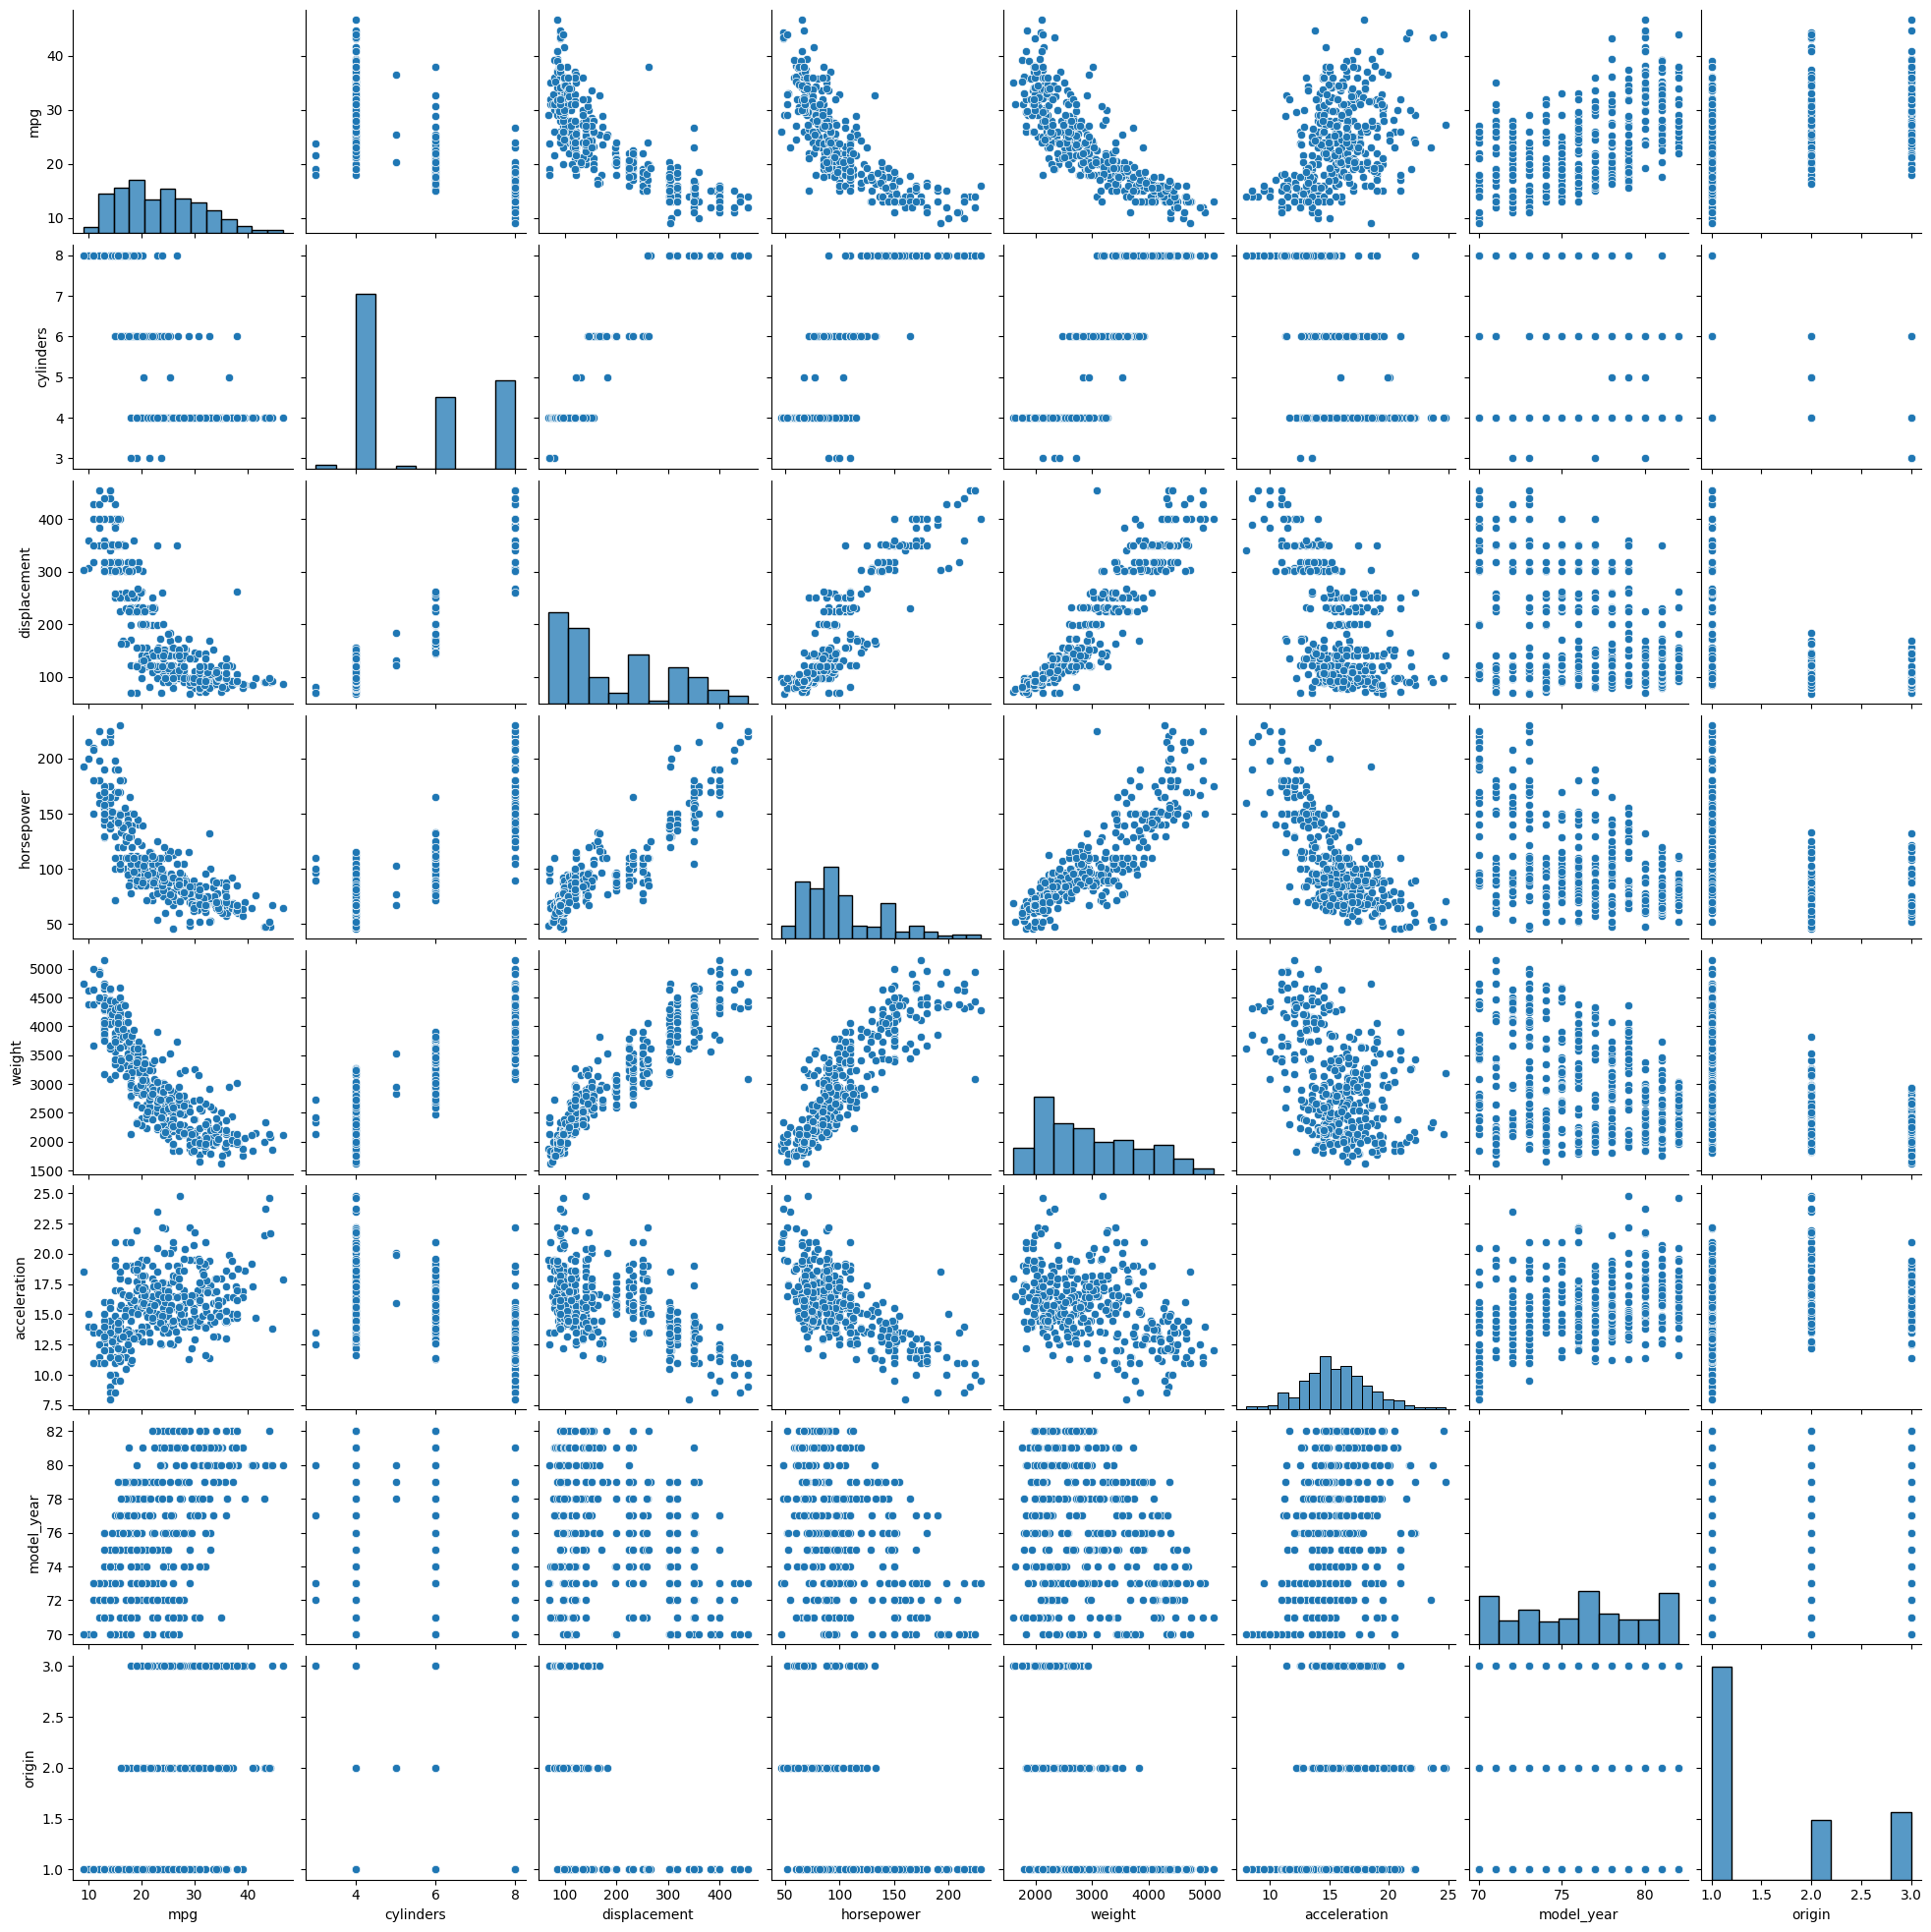

In [12]:
pairplot(df)

Посмторим на распределение категориальных переменных.

In [13]:
df["cylinders"].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [14]:
df["origin"].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

Выясним, содержатся ли выбросы в данных.

<Axes: >

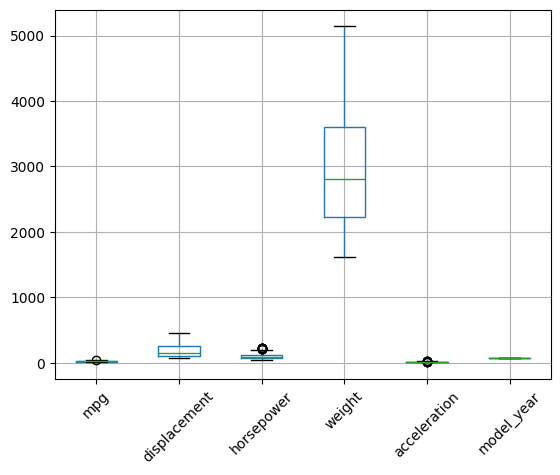

In [15]:
df[["mpg", "displacement", "horsepower", "weight",
    "acceleration", "model_year"]].boxplot(rot=45)

Выбросы есть, но их немного, и они не критичные. Убирать их не будем.

Сформируем конвейеры для обработки количественных и категориальных данных.

In [16]:
numeric_features = ["displacement", "horsepower", "weight", 
                    "acceleration", "model_year"]
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), 
        ("scaler", StandardScaler()),
    ]
)

In [17]:
categorical_features = ["cylinders", "origin"]
categorical_transformer = Pipeline(
    steps=[
        ("onehot-encoder", OneHotEncoder(drop="first", 
                                         handle_unknown="ignore")),
    ]
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

In [19]:
regressor = Ridge()
tr_regressor = TransformedTargetRegressor(regressor=regressor,
                                          transformer=MinMaxScaler())
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", tr_regressor)
    ]
)

In [20]:
train, test = train_test_split(df, test_size=0.3)

In [21]:
train.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
244,43.1,4,90.0,48.0,1985.0,21.5,78,2
30,28.0,4,140.0,90.0,2264.0,15.5,71,1
269,30.9,4,105.0,75.0,2230.0,14.5,78,1
187,17.5,8,305.0,140.0,4215.0,13.0,76,1
38,14.0,8,350.0,165.0,4209.0,12.0,71,1


In [22]:
X_train = train[["cylinders", 
                 "displacement", 
                 "horsepower", 
                 "weight", 
                 "acceleration", 
                 "model_year", 
                 "origin",
                ]]
Y_train = train[["mpg"]]

In [23]:
X_test = test[["cylinders", 
               "displacement", 
               "horsepower", 
               "weight", 
               "acceleration", 
               "model_year", 
               "origin",
              ]]
Y_test = test[["mpg"]]

Подберем коэффициент регуляризации для линейной регрессии.

In [24]:
param_grid = {
    "regressor__regressor__alpha": np.linspace(0.0, 3.0, num=31),
}

In [25]:
search_cv = GridSearchCV(pipe, param_grid)

In [26]:
search_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...axScaler()))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__regressor__alpha': array([0. , 0....8, 2.9, 3. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [27]:
print("Best params:")
print(search_cv.best_params_)

Best params:
{'regressor__regressor__alpha': np.float64(3.0)}


In [28]:
search_cv.score(X_train, Y_train)

0.8342987758957321

In [29]:
search_cv.score(X_test, Y_test)

0.8598427196129658

Сохраним полученный конвейер обработки данных для дальнейшего использования.

In [ ]:
Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/pipeline.pkl", "wb") as file:
    dump(search_cv, file)